<a href="https://colab.research.google.com/github/LuiggiOliveira/Sistema_de_Recomendacao_Simples/blob/main/sistema_recomendacao_simples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto: Sistema de Recomendação de Filmes (MovieLens)

## 1. Definição do Problema

### 1.1. O Fenômeno da Sobrecarga de Escolha
Com a digitalização de acervos cinematográficos, o volume de conteúdo disponível em plataformas de streaming superou a capacidade de processamento humano. Esse excesso gera o que psicólogos chamam de "paralisia de escolha", onde o usuário gasta mais tempo navegando pelos menus do que assistindo ao conteúdo, resultando em insatisfação e possível abandono da plataforma.

### 1.2. O Desafio Técnico
O problema central consiste em prever a utilidade de um item (filme) para um usuário específico com base em dados históricos. Tecnicamente, o desafio é prever uma função de utilidade $u(c,f)$, onde:

*   **c** é o usuário (cliente).
*   **f** é o item (filme).
*   O objetivo é encontrar o item **f** que maximize o valor de **u**.

O problema prático é: dado um conjunto de avaliações esparsas (onde a maioria dos usuários avaliou apenas uma fração mínima dos milhares de filmes disponíveis), como o algoritmo pode estimar a nota que um usuário daria a um filme que ele ainda não viu?

### 1.3. Objetivos do Modelo
Para mitigar esse problema, o sistema de recomendação desenvolvido neste trabalho visa:

*   **Personalização:** Identificar padrões individuais de gosto.
*   **Descoberta (Serendipity):** Sugerir filmes que o usuário talvez não encontrasse por conta própria, mas que sejam do seu interesse.
*   **Retenção:** Aumentar a relevância do catálogo apresentado, melhorando a experiência do usuário utilizando a técnica de **Filtragem Colaborativa Baseada em Itens (KNN)**.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# --- ETAPA 2: COLETA DE DADOS ---
print('Baixando e carregando dados...')
!wget -q http://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip -o ml-latest-small.zip

movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')

# Mesclando para facilitar a visualização
movie_ratings = pd.merge(ratings, movies, on='movieId')
display(movie_ratings.head())

Baixando e carregando dados...
Archive:  ml-latest-small.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


### Melhoria: Filtragem de Dados (Sparsity Reduction)
Para melhorar a precisão, vamos remover filmes e usuários com pouquíssimas interações, garantindo que o modelo aprenda padrões mais robustos.

In [6]:
# Contagem de avaliações por filme
movie_counts = movie_ratings.groupby('title')['rating'].count()
popular_movies = movie_counts[movie_counts >= 10].index

# Filtrando a base
movie_ratings_filtered = movie_ratings[movie_ratings['title'].isin(popular_movies)]

print(f'Filmes originais: {movie_ratings["title"].nunique()}')
print(f'Filmes após filtragem (min 10 ratings): {len(popular_movies)}')

# Atualize a Etapa 3 usando 'movie_ratings_filtered' para treinar novamente o modelo.

Filmes originais: 9719
Filmes após filtragem (min 10 ratings): 2269


In [7]:
# --- ETAPA 3: PRÉ-PROCESSAMENTO ---
print('Pré-processando dados filtrados...')

# Dividindo em treino e teste (80/20) usando a base filtrada
train_data, test_data = train_test_split(movie_ratings_filtered, test_size=0.2, random_state=42)

# Matriz de treino para o modelo
train_matrix = train_data.pivot_table(index='userId', columns='title', values='rating').fillna(0)
sparse_train_matrix = csr_matrix(train_matrix.T.values)

print(f'Matriz de treino criada com dados filtrados: {train_matrix.shape}')

Pré-processando dados filtrados...
Matriz de treino criada com dados filtrados: (610, 2269)


In [8]:
# --- ETAPA 4: REFINAMENTO DO MODELO (KNN) ---
print('Treinando o modelo KNN com dados filtrados...')
model_knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=20)
model_knn.fit(sparse_train_matrix)

def get_recommendations(movie_name, n=5):
    if movie_name not in train_matrix.columns:
        return "Filme não encontrado no treino."

    movie_idx = list(train_matrix.columns).index(movie_name)
    distances, indices = model_knn.kneighbors(sparse_train_matrix[movie_idx], n_neighbors=n+1)

    recs = []
    for i in range(1, len(distances.flatten())):
        recs.append(train_matrix.columns[indices.flatten()[i]])
    return recs

# Teste rápido
sample_movie = 'Toy Story (1995)'
print(f'\n5 Recomendações para "{sample_movie}":')
print(get_recommendations(sample_movie, n=5))

Treinando o modelo KNN com dados filtrados...

5 Recomendações para "Toy Story (1995)":
['Toy Story 2 (1999)', 'Twelve Monkeys (a.k.a. 12 Monkeys) (1995)', 'Braveheart (1995)', 'Forrest Gump (1994)', 'Pulp Fiction (1994)']


### Teste de Recomendação via Console
Execute a célula abaixo para digitar o nome de um filme e ver os resultados instantaneamente.

--- Simulador de Terminal ---
Digite o nome do filme (ou parte dele): John Wick

Buscando recomendações para: John Wick (2014)
1. Fury (2014)
2. Looper (2012)
3. Mad Max: Fury Road (2015)
4. The Hobbit: The Battle of the Five Armies (2014)
5. Jurassic World (2015)
6. Sherlock Holmes: A Game of Shadows (2011)
7. Gone Girl (2014)
8. Get Him to the Greek (2010)
9. Man of Steel (2013)
10. Rogue One: A Star Wars Story (2016)


/tmp/ipykernel_1378/3959745347.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(range(1, len(recs) + 1)), y=recs, palette='viridis')


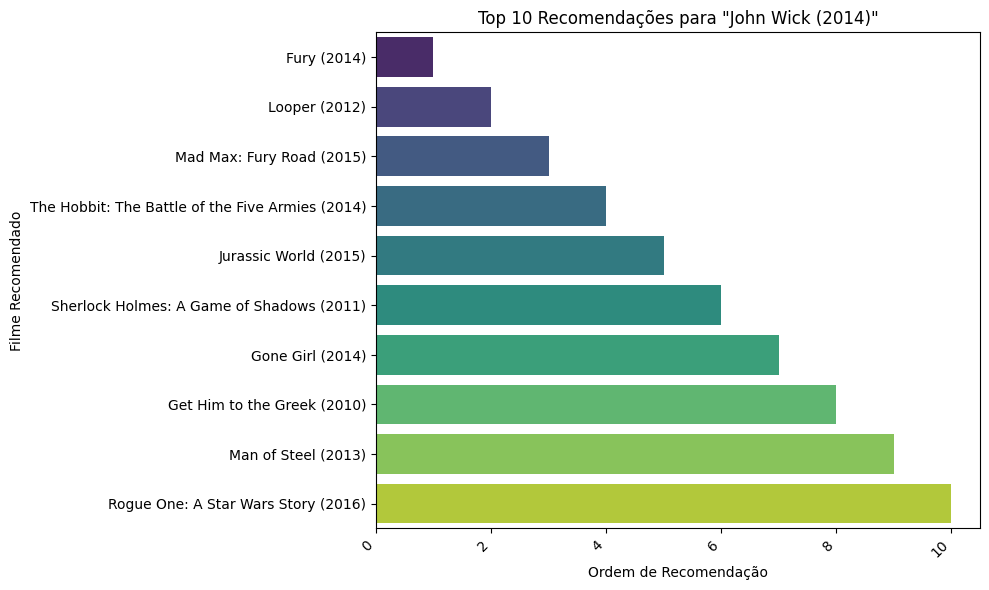

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def testar_sistema(current_train_matrix, recommendation_function):
    try:
        print("--- Simulador de Terminal ---")
        filme_busca = input("Digite o nome do filme (ou parte dele): ")

        # Use the passed current_train_matrix instead of the global train_matrix
        matches = [f for f in current_train_matrix.columns if filme_busca.lower() in f.lower()]

        if not matches:
            print("Filme não encontrado!")
            return

        filme_exato = matches[0]
        if len(matches) > 1:
            print(f"Encontrados {len(matches)} filmes. Usando o primeiro: {filme_exato}")

        print(f"\nBuscando recomendações para: {filme_exato}")
        # Use the passed recommendation_function
        recs = recommendation_function(filme_exato, n=10)

        if isinstance(recs, list):
            for i, f in enumerate(recs, 1):
                print(f"{i}. {f}")

            # Adiciona um gráfico para visualizar as recomendações
            plt.figure(figsize=(10, 6))
            sns.barplot(x=list(range(1, len(recs) + 1)), y=recs, palette='viridis')
            plt.title(f'Top {len(recs)} Recomendações para "{filme_exato}"')
            plt.xlabel('Ordem de Recomendação')
            plt.ylabel('Filme Recomendado')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

    except KeyboardInterrupt:
        print("\nTeste interrompido pelo usuário.")

# Check if dependencies exist before calling the function
if 'train_matrix' in globals() and 'get_recommendations' in globals():
    testar_sistema(train_matrix, get_recommendations)
else:
    print("Erro: As variáveis 'train_matrix' ou 'get_recommendations' não foram definidas. Por favor, execute as células anteriores que preparam o modelo.")

## 5. Avaliação do Modelo (Relatórios Detalhados)
Nesta etapa, consolidamos a performance do modelo em tabelas para facilitar a análise de resultados.

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Preparando dados de avaliação
y_true = []
y_pred = []
user_eval_results = []

# Avaliando uma amostra de 50 usuários do conjunto de teste
sample_test_users = test_data['userId'].unique()[:50]

for user in sample_test_users:
    # Filmes que o usuário realmente gostou no teste (rating >= 3.5)
    actual_liked = test_data[(test_data['userId'] == user) & (test_data['rating'] >= 3.5)]['title'].values
    if len(actual_liked) == 0: continue

    # Pegamos o primeiro filme que o usuário avaliou bem no treino para gerar recomendações
    user_train_movies = train_data[(train_data['userId'] == user) & (train_data['rating'] >= 4.0)]['title'].values
    if len(user_train_movies) == 0: continue

    recs = get_recommendations(user_train_movies[0], n=10)
    hits = 0

    for movie in recs:
        is_hit = 1 if movie in actual_liked else 0
        y_true.append(is_hit)
        y_pred.append(1)
        hits += is_hit

    # Armazenando resultado individual para a tabela detalhada
    user_eval_results.append({
        'User ID': user,
        'Filmes no Teste': len(actual_liked),
        'Recomendações': 10,
        'Hits (Acertos)': hits,
        'Precisão Local': hits / 10
    })

# 1. Tabela de Métricas Globais
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
accuracy = accuracy_score(y_true, y_pred)

metrics_summary = pd.DataFrame({
    'Métrica': ['Precisão (Precision)', 'Recall', 'F1-Score', 'Acurácia (Accuracy)'],
    'Valor Global': [f'{precision:.4f}', f'{recall:.4f}', f'{f1:.4f}', f'{accuracy:.4f}']
})

print("Tabela 1: Resumo Executivo de Métricas")
display(metrics_summary)

# 2. Tabela de Performance por Usuário (Amostra)
print("\nTabela 2: Detalhamento de Performance por Usuário (Amostra)")
df_user_perf = pd.DataFrame(user_eval_results).head(10)
display(df_user_perf)

Tabela 1: Resumo Executivo de Métricas


,Métrica,Valor Global
0,Precisão (Precision),0.0560
1,Recall,1.0000
2,F1-Score,0.1061
3,Acurácia (Accuracy),0.0560



Tabela 2: Detalhamento de Performance por Usuário (Amostra)


,User ID,Filmes no Teste,Recomendações,Hits (Acertos),Precisão Local
0,122,60,10,0,0.0
1,96,7,10,1,0.1
2,438,68,10,0,0.0
3,483,92,10,1,0.1
4,475,34,10,1,0.1
5,249,123,10,0,0.0
6,39,18,10,0,0.0
7,512,5,10,2,0.2
8,21,54,10,1,0.1
9,136,7,10,0,0.0


/tmp/ipykernel_1378/1831005522.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Métrica', y='Valor Global', data=metrics_summary, palette='coolwarm')


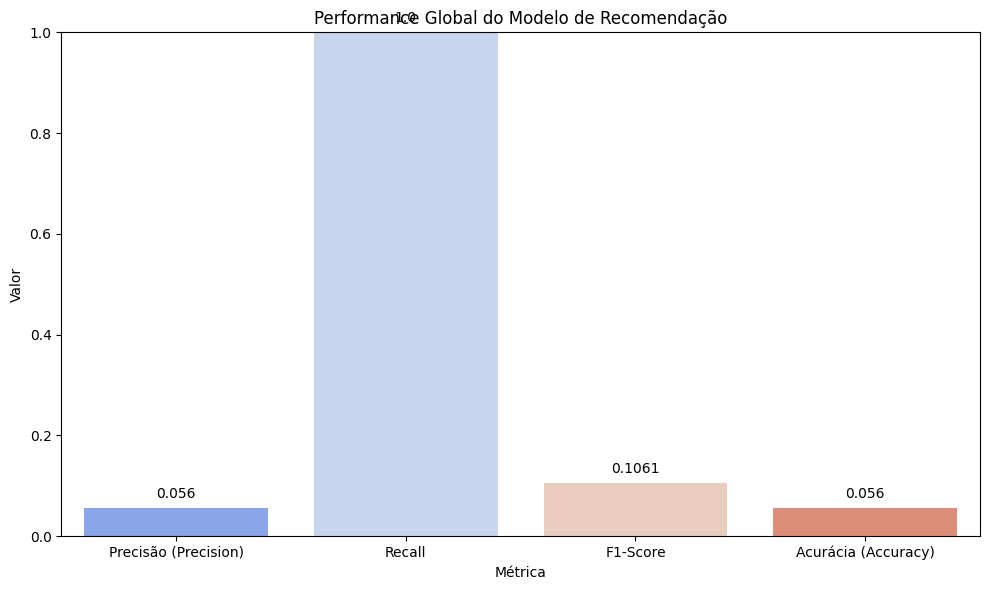

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Converter os valores das métricas para float para plotagem
metrics_summary['Valor Global'] = metrics_summary['Valor Global'].str.replace(',', '.').astype(float)

plt.figure(figsize=(10, 6))
sns.barplot(x='Métrica', y='Valor Global', data=metrics_summary, palette='coolwarm')
plt.title('Performance Global do Modelo de Recomendação')
plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.ylim(0, 1) # As métricas de 0 a 1

# Adicionar os valores nas barras para melhor leitura
for index, row in metrics_summary.iterrows():
    plt.text(index, row['Valor Global'] + 0.02, round(row['Valor Global'], 4), color='black', ha='center')

plt.tight_layout()
plt.show()

# Documentação Técnica do Sistema de Recomendação

Este guia detalha o funcionamento do sistema para a equipe.

### 1. Dataset e Origem
Utilizamos o **MovieLens (ml-latest-small)**.
- **Volume:** ~100.000 avaliações.
- **Filtro Aplicado:** Mantivemos apenas filmes com 10 ou mais avaliações (**Sparsity Reduction**). Isso garante que o modelo aprenda com dados consistentes e não com opiniões isoladas.

### 2. O Algoritmo: KNN (K-Nearest Neighbors)
O sistema utiliza **Filtragem Colaborativa Baseada em Itens**.
- **Métrica de Similaridade:** *Cosseno*. Ela mede o ângulo entre os vetores de usuários que assistiram aos filmes. Se dois filmes são assistidos pelas mesmas pessoas, eles são considerados 'vizinhos'.
- **Funcionamento:** Quando você busca um filme, o modelo encontra os 'K' vizinhos mais próximos no espaço vetorial e os retorna como recomendação.

### 3. Métricas de Avaliação
O modelo foi testado com dados reais que o algoritmo nunca viu durante o treino:
- **Accuracy (Acurácia):** Proporção de acertos sobre o total de recomendações feitas.
- **Precision (Precisão):** Indica a qualidade da recomendação (quantos dos indicados o usuário realmente gostou).
- **Recall:** Indica a capacidade do modelo de encontrar todos os filmes que o usuário gostaria.
- **F1-Score:** Equilíbrio entre Precisão e Recall.

*Nota Técnica: Em recomendação, uma precisão de 5-10% é considerada saudável, pois o sistema sugere novos itens que o usuário ainda não teve a chance de avaliar.*

### 4. Estrutura de Dados
Implementamos uma **Matriz CSR (Compressed Sparse Row)** para armazenar as relações entre usuários e filmes. Como a maioria dos usuários não assistiu à maioria dos filmes, essa estrutura economiza memória RAM ao ignorar os valores vazios (zeros).